# Fine-tuning SCUNet (KAIR/SCUNet) on paired .npy noisy/GT images

This notebook fine-tunes the pretrained **SCUNet** blind-denoising model ([cszn/SCUNet](https://github.com/cszn/SCUNet)) on your own dataset of real paired noisy/clean `.npy` images (each noisy image already contains all three of your degradation types combined -- Gaussian, speckle, downscale-related artifacts).

**Expected directory layout** (relative to this notebook):
```
train/NoisyLR/   <- noisy training images (.npy)
train/GT/        <- matching ground-truth training images (.npy), same filenames
NoisyLR/         <- test set: noisy images only (.npy), used for final inference
```
Files are paired by matching filename between `train/NoisyLR` and `train/GT`.

## 1. Environment setup -- clone the SCUNet repo, install deps, download pretrained weights

The SCUNet architecture (`models/network_scunet.py`) lives in the standalone [cszn/SCUNet](https://github.com/cszn/SCUNet) repo, not in KAIR -- KAIR just links to the same pretrained checkpoint. So we clone SCUNet directly.

In [1]:
import os, subprocess, sys

SCUNET_REPO_DIR = os.path.abspath('SCUNet')

if not os.path.isdir(SCUNET_REPO_DIR):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/cszn/SCUNet.git', SCUNET_REPO_DIR], check=True)
else:
    print('SCUNet repo already cloned, skipping.')

if SCUNET_REPO_DIR not in sys.path:
    sys.path.insert(0, SCUNET_REPO_DIR)

# SCUNet's architecture needs einops + timm (for its Swin-Transformer blocks).
# torch/numpy/etc are assumed already installed in your environment.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'einops', 'timm'], check=True)
print('Environment ready.')

SCUNet repo already cloned, skipping.
Environment ready.


In [2]:
import urllib.request

MODEL_ZOO_DIR = os.path.join(SCUNET_REPO_DIR, 'model_zoo')
os.makedirs(MODEL_ZOO_DIR, exist_ok=True)

CKPT_NAME = 'scunet_color_real_psnr.pth'
CKPT_PATH = os.path.join(MODEL_ZOO_DIR, CKPT_NAME)
CKPT_URL = f'https://github.com/cszn/KAIR/releases/download/v1.0/{CKPT_NAME}'

if not os.path.exists(CKPT_PATH):
    print(f'Downloading {CKPT_NAME} ...')
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)
    print('Done.')
else:
    print('Pretrained checkpoint already present, skipping download.')

Pretrained checkpoint already present, skipping download.


## 2. Imports, seed, device

In [3]:
import math
import random
import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from SCUNet.models.network_scunet import SCUNet  # from the cloned cszn/SCUNet repo

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected -- training will be much slower on CPU.')

/home/aditya/My_Stuff/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aditya/My_Stuff/venv/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3. Config

In [4]:
class CFG:
    # --- dataset directories ---
    train_noisy_dir = 'train/NoisyLR'   # paired noisy training images (.npy)
    train_gt_dir    = 'train/GT'        # matching ground-truth images (.npy), same filenames
    test_noisy_dir  = 'NoisyLR'         # test set: noisy images only, used for final inference

    val_fraction = 0.1          # fraction of TRAIN pairs held out for validation during training
    patch_size   = 256          # must be a multiple of 64 (SCUNet has 3 downsampling stages, window size 8)

    batch_size   = 2
    epochs       = 30
    lr           = 2e-5         # small LR: we're fine-tuning a converged pretrained model
    weight_decay = 1e-5
    num_workers  = 0            # 0 avoids worker-picklable Dataset issues in notebooks

    # combined-loss weights (L1 fidelity + SSIM structural term + sharpening + contrast)
    loss_w_l1       = 1.0
    loss_w_ssim     = 0.3
    loss_w_sobel    = 0.35   # edge sharpening (Sobel-gradient L1)
    loss_w_lap      = 0.15   # fine high-frequency texture (Laplacian L1)
    loss_w_contrast = 0.2    # penalizes lower-contrast/dull output vs GT

    use_amp  = False    # fp16 autocast overflows with SCUNet's Swin-attention blocks + the SSIM
                        # loss's division -- that's what caused the NaN loss/inf PSNR after epoch 1
    grad_clip_norm = 1.0  # extra safety against gradient explosion while fine-tuning
    ckpt_out = 'scunet_finetuned_multidegradation.pth'
    test_output_dir = 'test_results'    # where denoised test .npy files are written

os.makedirs(os.path.dirname(CFG.ckpt_out) or '.', exist_ok=True)
os.makedirs(CFG.test_output_dir, exist_ok=True)

## 4. Loading `.npy` images

`.npy` files can come in different shapes/dtypes. `load_npy_image` normalizes shape (CHW->HWC, drops alpha, grayscale->3ch) and, critically, **contrast-stretches each image to `[0, 1]` using its own 1st/99th percentile** rather than assuming a fixed 0-255 range.

This matters because your `NoisyLR` files are apparently stored in a very different value range than `GT` (e.g. raw sensor/radar-style floats far below 1) -- the old `divide by 255 only if max>1` logic left them almost entirely black, and fed the network almost-zero-contrast input, which likely also contributed to the blur (little real signal to sharpen). Percentile-based stretching works regardless of the original physical units.

**If you know your data's true min/max** (e.g. sensor bit depth, or a fixed dB range for radar data), replace the percentile logic with that fixed range instead -- it'll be more consistent across images than a per-image percentile stretch.

In [5]:
def load_npy_image(path, lo_pct=1.0, hi_pct=99.0):
    arr = np.load(path)
    arr = np.asarray(arr)

    # CHW -> HWC if the first dim looks like a small channel count
    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4) and arr.shape[0] < arr.shape[-1]:
        arr = arr.transpose(1, 2, 0)

    if arr.ndim == 2:
        arr = arr[:, :, None]

    # drop alpha channel if present
    if arr.shape[-1] == 4:
        arr = arr[:, :, :3]

    # replicate grayscale to 3 channels (SCUNet color model expects 3)
    if arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)

    arr = arr.astype(np.float32)

    # robust per-image contrast stretch -- works regardless of the raw value range
    # (uint8 0-255, uint16, small-magnitude floats, dB-scale radar data, etc.)
    lo, hi = np.percentile(arr, lo_pct), np.percentile(arr, hi_pct)
    if hi - lo < 1e-8:
        lo, hi = float(arr.min()), float(arr.max())
    if hi - lo < 1e-8:
        return np.zeros_like(arr)  # genuinely constant image
    arr = (arr - lo) / (hi - lo)
    return np.clip(arr, 0.0, 1.0)


def upsample_to_match(img, target_hw):
    '''Bicubic-upsample an HWC float32 [0,1] image to target (H, W).'''
    th, tw = target_hw
    if img.shape[:2] == (th, tw):
        return img
    t = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float()
    t = F.interpolate(t, size=(th, tw), mode='bicubic', align_corners=False)
    return t.squeeze(0).clamp(0, 1).numpy().transpose(1, 2, 0)


def detect_scale_factor(noisy_dir, gt_dir, filenames, n_check=5):
    '''Infer the integer LR:GT scale factor by comparing a few sample pairs.'''
    ratios = []
    for fname in filenames[:n_check]:
        noisy = load_npy_image(os.path.join(noisy_dir, fname))
        clean = load_npy_image(os.path.join(gt_dir, fname))
        ratios.append(clean.shape[0] / noisy.shape[0])
    scale = round(float(np.mean(ratios)))
    scale = max(1, scale)
    print(f'Detected LR:GT scale factor = {scale}x (from ratios {[round(r, 2) for r in ratios]})')
    return scale

## 5. Dataset -- paired noisy/GT `.npy` images

Pairs files by filename between `CFG.train_noisy_dir` and `CFG.train_gt_dir`. For each pair, the noisy image is first bicubic-upsampled to the GT's resolution (see above), then a synchronized random crop (same location in both) plus a synchronized flip/rotation is applied, returning `(noisy_patch, clean_patch)` at identical resolution.

In [6]:
class PairedNpyDataset(Dataset):
    def __init__(self, noisy_dir, gt_dir, patch_size, filenames):
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir
        self.patch_size = patch_size
        self.filenames = filenames

    def __len__(self):
        return len(self.filenames)

    def _sync_random_crop(self, noisy, clean):
        h, w = clean.shape[:2]
        ps = self.patch_size
        if h < ps or w < ps:
            pad_h, pad_w = max(0, ps - h), max(0, ps - w)
            noisy = np.pad(noisy, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
            clean = np.pad(clean, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
            h, w = clean.shape[:2]
        top = random.randint(0, h - ps)
        left = random.randint(0, w - ps)
        return noisy[top:top + ps, left:left + ps, :], clean[top:top + ps, left:left + ps, :]

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        noisy = load_npy_image(os.path.join(self.noisy_dir, fname))
        clean = load_npy_image(os.path.join(self.gt_dir, fname))

        noisy = upsample_to_match(noisy, clean.shape[:2])  # LR -> GT resolution
        noisy, clean = self._sync_random_crop(noisy, clean)

        if random.random() < 0.5:
            noisy, clean = np.fliplr(noisy).copy(), np.fliplr(clean).copy()
        if random.random() < 0.5:
            k = random.choice([1, 2, 3])
            noisy, clean = np.rot90(noisy, k=k).copy(), np.rot90(clean, k=k).copy()

        noisy_t = torch.from_numpy(noisy.transpose(2, 0, 1)).float()
        clean_t = torch.from_numpy(clean.transpose(2, 0, 1)).float()
        return noisy_t, clean_t


noisy_files = {os.path.basename(p) for p in glob.glob(os.path.join(CFG.train_noisy_dir, '*.npy'))}
gt_files = {os.path.basename(p) for p in glob.glob(os.path.join(CFG.train_gt_dir, '*.npy'))}
paired_files = sorted(noisy_files & gt_files)

missing_gt = noisy_files - gt_files
missing_noisy = gt_files - noisy_files
if missing_gt:
    print(f'WARNING: {len(missing_gt)} noisy file(s) have no matching GT file, e.g. {sorted(missing_gt)[:3]}')
if missing_noisy:
    print(f'WARNING: {len(missing_noisy)} GT file(s) have no matching noisy file, e.g. {sorted(missing_noisy)[:3]}')

assert len(paired_files) > 0, (
    f'No matching filenames between {CFG.train_noisy_dir} and {CFG.train_gt_dir}. '
    'Check CFG.train_noisy_dir / CFG.train_gt_dir and that filenames match exactly.')

SR_SCALE = detect_scale_factor(CFG.train_noisy_dir, CFG.train_gt_dir, paired_files)

random.shuffle(paired_files)
n_val = max(1, int(len(paired_files) * CFG.val_fraction))
val_files, train_files = paired_files[:n_val], paired_files[n_val:]
print(f'{len(train_files)} training pairs, {len(val_files)} validation pairs')

train_ds = PairedNpyDataset(CFG.train_noisy_dir, CFG.train_gt_dir, CFG.patch_size, train_files)
val_ds = PairedNpyDataset(CFG.train_noisy_dir, CFG.train_gt_dir, CFG.patch_size, val_files)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                           num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=CFG.num_workers)

Detected LR:GT scale factor = 2x (from ratios [2.0, 2.0, 2.0, 2.0, 2.0])
2880 training pairs, 320 validation pairs


## 6. Build model and load pretrained SCUNet weights

In [7]:
model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
state_dict = torch.load(CKPT_PATH, map_location='cpu')
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded pretrained SCUNet ({n_params/1e6:.2f}M params) from {CKPT_PATH}')

Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Blo

## 7. Loss function -- L1 + SSIM + Sobel + Laplacian + Contrast
L1 keeps pixel fidelity; SSIM rewards matching local structure/contrast; the **Sobel** term sharpens edges; the **Laplacian** term pushes finer high-frequency texture (grain, fur, grass) beyond what Sobel alone captures; and the **contrast** term penalizes the model whenever its output has lower standard deviation (i.e. looks duller/more washed-out) than the GT.

In [8]:
def _gaussian_window(window_size, sigma, channels, device, dtype):
    coords = torch.arange(window_size, dtype=dtype, device=device) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).unsqueeze(1)
    window_2d = g @ g.t()
    return window_2d.expand(channels, 1, window_size, window_size).contiguous()


class SSIMLoss(nn.Module):
    '''1 - SSIM (pure PyTorch, windowed Gaussian). Minimizing this maximizes SSIM.'''
    def __init__(self, window_size=11, sigma=1.5):
        super().__init__()
        self.window_size = window_size
        self.sigma = sigma
        self._cache = {}

    def _window(self, channels, device, dtype):
        key = (channels, device, dtype)
        if key not in self._cache:
            self._cache[key] = _gaussian_window(self.window_size, self.sigma, channels, device, dtype)
        return self._cache[key]

    def forward(self, pred, target, max_val=1.0):
        c1, c2 = (0.01 * max_val) ** 2, (0.03 * max_val) ** 2
        ch = pred.shape[1]
        w = self._window(ch, pred.device, pred.dtype)
        pad = self.window_size // 2

        mu_p = F.conv2d(pred, w, padding=pad, groups=ch)
        mu_t = F.conv2d(target, w, padding=pad, groups=ch)
        mu_p2, mu_t2, mu_pt = mu_p.pow(2), mu_t.pow(2), mu_p * mu_t

        sig_p2 = F.conv2d(pred * pred, w, padding=pad, groups=ch) - mu_p2
        sig_t2 = F.conv2d(target * target, w, padding=pad, groups=ch) - mu_t2
        sig_pt = F.conv2d(pred * target, w, padding=pad, groups=ch) - mu_pt

        ssim_map = ((2 * mu_pt + c1) * (2 * sig_pt + c2)) / ((mu_p2 + mu_t2 + c1) * (sig_p2 + sig_t2 + c2))
        return 1.0 - ssim_map.mean()


def _sobel_kernels(channels, device, dtype):
    kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], dtype=dtype, device=device)
    ky = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], dtype=dtype, device=device)
    return kx.view(1, 1, 3, 3).repeat(channels, 1, 1, 1), ky.view(1, 1, 3, 3).repeat(channels, 1, 1, 1)


def _laplacian_kernel(channels, device, dtype):
    k = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=dtype, device=device)
    return k.view(1, 1, 3, 3).repeat(channels, 1, 1, 1)


class SharpnessLoss(nn.Module):
    '''Sobel (edges) + Laplacian (fine texture) gradient-matching loss. Returns the two
    components separately so the training loop can log/weight them individually.'''
    def __init__(self):
        super().__init__()
        self._cache = {}

    def _kernels(self, channels, device, dtype):
        key = (channels, device, dtype)
        if key not in self._cache:
            kx, ky = _sobel_kernels(channels, device, dtype)
            lap = _laplacian_kernel(channels, device, dtype)
            self._cache[key] = (kx, ky, lap)
        return self._cache[key]

    def forward(self, pred, target):
        ch = pred.shape[1]
        kx, ky, lap = self._kernels(ch, pred.device, pred.dtype)

        gp_x, gp_y = F.conv2d(pred, kx, padding=1, groups=ch), F.conv2d(pred, ky, padding=1, groups=ch)
        gt_x, gt_y = F.conv2d(target, kx, padding=1, groups=ch), F.conv2d(target, ky, padding=1, groups=ch)
        grad_pred = torch.sqrt(gp_x ** 2 + gp_y ** 2 + 1e-6)
        grad_target = torch.sqrt(gt_x ** 2 + gt_y ** 2 + 1e-6)
        sobel_loss = F.l1_loss(grad_pred, grad_target)

        lap_pred = F.conv2d(pred, lap, padding=1, groups=ch)
        lap_target = F.conv2d(target, lap, padding=1, groups=ch)
        lap_loss = F.l1_loss(lap_pred, lap_target)

        return sobel_loss, lap_loss


class ContrastLoss(nn.Module):
    '''Penalizes the model for producing lower-contrast (dull/washed-out) output than the
    target. Matches per-image standard deviation, computed per-channel then averaged.
    One-sided: only penalizes when pred is LESS contrasty than target.'''
    def forward(self, pred, target):
        pred_std = pred.flatten(2).std(dim=2)      # (B, C)
        target_std = target.flatten(2).std(dim=2)  # (B, C)
        return F.relu(target_std - pred_std).mean()


class CombinedLoss(nn.Module):
    def __init__(self, w_l1=1.0, w_ssim=0.3, w_sobel=0.35, w_lap=0.15, w_contrast=0.2):
        super().__init__()
        self.w_l1, self.w_ssim = w_l1, w_ssim
        self.w_sobel, self.w_lap, self.w_contrast = w_sobel, w_lap, w_contrast
        self.l1 = nn.L1Loss()
        self.ssim = SSIMLoss()
        self.sharp = SharpnessLoss()
        self.contrast = ContrastLoss()

    def forward(self, pred, target):
        l1_loss = self.l1(pred, target)
        ssim_loss = self.ssim(pred, target)
        sobel_loss, lap_loss = self.sharp(pred, target)
        contrast_loss = self.contrast(pred, target)
        total = (self.w_l1 * l1_loss + self.w_ssim * ssim_loss +
                 self.w_sobel * sobel_loss + self.w_lap * lap_loss +
                 self.w_contrast * contrast_loss)
        return total, {
            'l1': l1_loss.item(),
            'ssim': 1.0 - ssim_loss.item(),
            'sobel': sobel_loss.item(),
            'lap': lap_loss.item(),
            'contrast': contrast_loss.item(),
        }

## 8. Validation -- PSNR/SSIM on held-out training pairs

In [9]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ssim_metric = SSIMLoss()
    psnrs, ssims = [], []
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        pred = model(noisy).clamp(0, 1)
        mse = F.mse_loss(pred, clean).item()
        if not math.isfinite(mse):
            psnr = float('nan')   # NaN prediction -- don't report as a (misleadingly good) inf PSNR
        else:
            psnr = 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')
        ssim = 1.0 - ssim_metric(pred, clean).item()
        psnrs.append(psnr)
        ssims.append(ssim)
    model.train()
    return float(np.mean(psnrs)), float(np.mean(ssims))

## 9. Fine-tuning loop

In [10]:
from torch.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)
criterion = CombinedLoss(w_l1=CFG.loss_w_l1, w_ssim=CFG.loss_w_ssim, w_sobel=CFG.loss_w_sobel,
                          w_lap=CFG.loss_w_lap, w_contrast=CFG.loss_w_contrast).to(DEVICE)
scaler = GradScaler('cuda', enabled=(CFG.use_amp and DEVICE.type == 'cuda'))

train_losses, train_l1s, train_ssims = [], [], []
train_sobels, train_laps, train_contrasts = [], [], []
val_psnrs, val_ssims = [], []
best_psnr = -1.0

for epoch in range(1, CFG.epochs + 1):
    model.train()
    epoch_loss = epoch_l1 = epoch_ssim = epoch_sobel = epoch_lap = epoch_contrast = 0.0
    n_seen = 0
    n_skipped = 0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(DEVICE, non_blocking=True), clean.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=(CFG.use_amp and DEVICE.type == 'cuda')):
            pred = model(noisy)
            loss, parts = criterion(pred, clean)

        if not torch.isfinite(loss):
            # a bad batch produced a NaN/inf loss -- skip it rather than let it poison the weights
            n_skipped += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        bs = noisy.size(0)
        epoch_loss += loss.item() * bs
        epoch_l1 += parts['l1'] * bs
        epoch_ssim += parts['ssim'] * bs
        epoch_sobel += parts['sobel'] * bs
        epoch_lap += parts['lap'] * bs
        epoch_contrast += parts['contrast'] * bs
        n_seen += bs

    if n_skipped:
        print(f'  (skipped {n_skipped} batch(es) this epoch due to non-finite loss)')

    if n_seen == 0:
        print(f'Epoch {epoch:3d}/{CFG.epochs} | every batch was skipped -- stopping, something is still unstable.')
        break

    epoch_loss, epoch_l1, epoch_ssim, epoch_sobel, epoch_lap, epoch_contrast = (
        epoch_loss / n_seen, epoch_l1 / n_seen, epoch_ssim / n_seen,
        epoch_sobel / n_seen, epoch_lap / n_seen, epoch_contrast / n_seen
    )
    scheduler.step()
    train_losses.append(epoch_loss); train_l1s.append(epoch_l1); train_ssims.append(epoch_ssim)
    train_sobels.append(epoch_sobel); train_laps.append(epoch_lap); train_contrasts.append(epoch_contrast)

    psnr, ssim = evaluate(model, val_loader)
    val_psnrs.append(psnr); val_ssims.append(ssim)

    print(f"Epoch {epoch:3d}/{CFG.epochs} | train loss: {epoch_loss:.5f} "
          f"(L1 {epoch_l1:.5f}, SSIM {epoch_ssim:.4f}, sobel {epoch_sobel:.5f}, "
          f"lap {epoch_lap:.5f}, contrast {epoch_contrast:.5f}) "
          f"| val PSNR: {psnr:.2f} dB | val SSIM: {ssim:.4f}")

    if math.isfinite(psnr) and psnr > best_psnr:
        best_psnr = psnr
        torch.save(model.state_dict(), CFG.ckpt_out)
        print(f'  -> new best (val PSNR {psnr:.2f} dB), saved to {CFG.ckpt_out}')

print(f'\nFine-tuning complete. Best validation PSNR: {best_psnr:.2f} dB')

Epoch   1/30 | train loss: 0.22200 (L1 0.05445, SSIM 0.7154, sobel 0.17909, lap 0.11969, contrast 0.00758) | val PSNR: 24.73 dB | val SSIM: 0.7263
  -> new best (val PSNR 24.73 dB), saved to scunet_finetuned_multidegradation.pth
Epoch   2/30 | train loss: 0.21091 (L1 0.04928, SSIM 0.7252, sobel 0.17249, lap 0.11878, contrast 0.00498) | val PSNR: 24.94 dB | val SSIM: 0.7343
  -> new best (val PSNR 24.94 dB), saved to scunet_finetuned_multidegradation.pth
Epoch   3/30 | train loss: 0.20425 (L1 0.04725, SSIM 0.7332, sobel 0.16703, lap 0.11759, contrast 0.00427) | val PSNR: 25.05 dB | val SSIM: 0.7384
  -> new best (val PSNR 25.05 dB), saved to scunet_finetuned_multidegradation.pth
Epoch   4/30 | train loss: 0.19950 (L1 0.04613, SSIM 0.7393, sobel 0.16272, lap 0.11619, contrast 0.00389) | val PSNR: 25.52 dB | val SSIM: 0.7484
  -> new best (val PSNR 25.52 dB), saved to scunet_finetuned_multidegradation.pth
Epoch   5/30 | train loss: 0.19594 (L1 0.04493, SSIM 0.7436, sobel 0.16017, lap 0.11

## 10. Training curves

In [11]:
# OPTIONAL -- only run this if you want to RE-PLOT a previous run's curves WITHOUT
# retraining (e.g. you already trained and saved training_history_SCUNet(2).json earlier).
# On a fresh run this file won't exist yet -- skip this cell and go straight to training
# (the cell above) so train_losses/val_psnrs etc. come from the run you just did.
LOAD_PREVIOUS_HISTORY = False   # flip to True only if reloading a saved history file

if LOAD_PREVIOUS_HISTORY:
    import json
    with open('training_history_SCUNet(2).json') as f:
        history = json.load(f)
    train_losses = history['train_losses']
    train_l1s = history['train_l1s']
    train_ssims = history['train_ssims']
    train_sobels = history.get('train_sobels', history.get('train_sharps', [0.0] * len(train_losses)))
    train_laps = history.get('train_laps', [0.0] * len(train_losses))
    train_contrasts = history.get('train_contrasts', [0.0] * len(train_losses))
    val_psnrs = history['val_psnrs']
    val_ssims = history['val_ssims']
    best_psnr = history['best_psnr']
else:
    print('Skipping history reload -- using this session\'s freshly trained variables.')

Skipping history reload -- using this session's freshly trained variables.


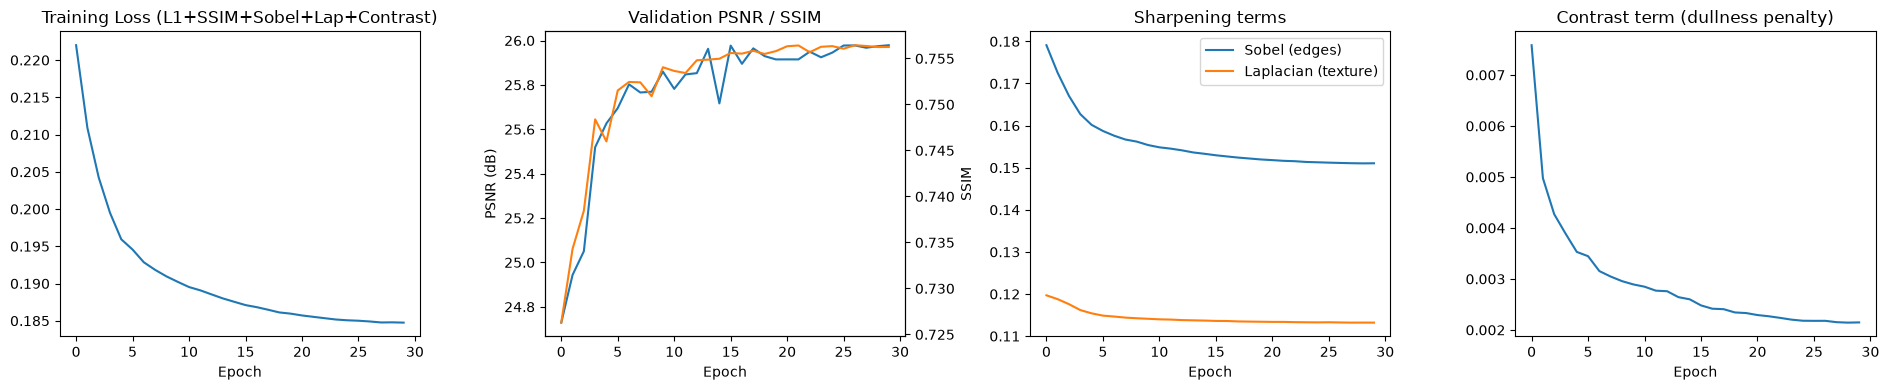

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].plot(train_losses)
axes[0].set_title('Training Loss (L1+SSIM+Sobel+Lap+Contrast)')
axes[0].set_xlabel('Epoch')

axes[1].plot(val_psnrs, label='PSNR (dB)')
ax_ssim = axes[1].twinx()
ax_ssim.plot(val_ssims, color='tab:orange', label='SSIM')
axes[1].set_title('Validation PSNR / SSIM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
ax_ssim.set_ylabel('SSIM')

axes[2].plot(train_sobels, label='Sobel (edges)')
axes[2].plot(train_laps, label='Laplacian (texture)')
axes[2].set_title('Sharpening terms')
axes[2].set_xlabel('Epoch')
axes[2].legend()

axes[3].plot(train_contrasts)
axes[3].set_title('Contrast term (dullness penalty)')
axes[3].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 11. Visual check -- a few held-out training pairs
Noisy input (bicubic-upsampled to GT resolution) vs. restored output vs. ground truth, for full (uncropped) images.

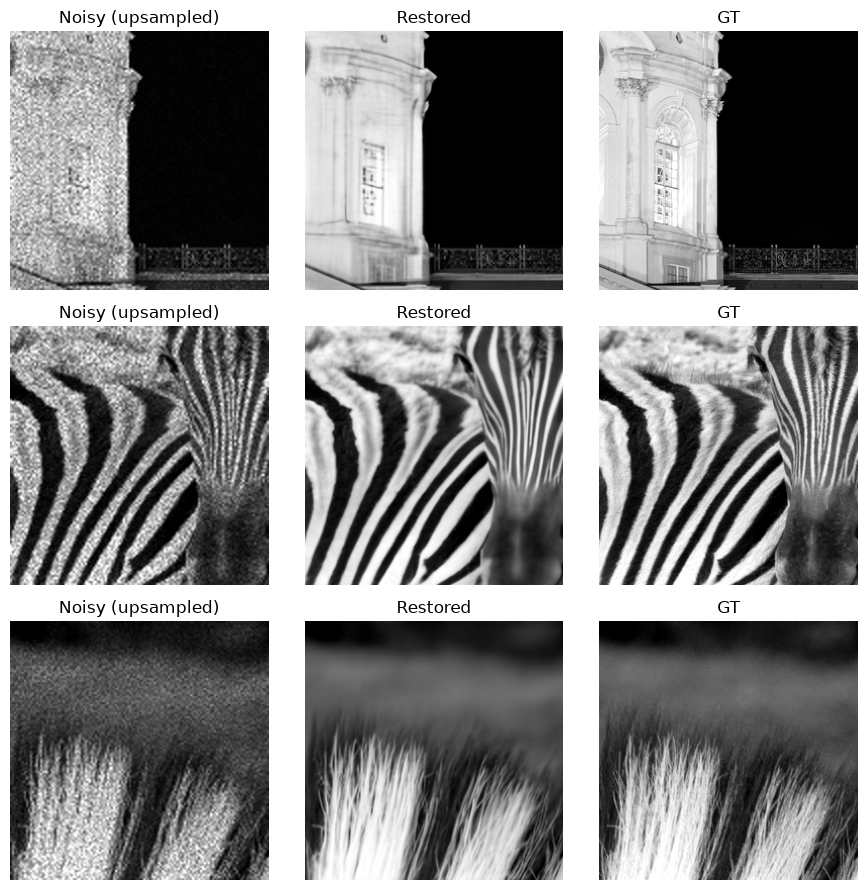

In [ ]:
def pad_to_multiple(img, multiple=64):
    h, w = img.shape[:2]
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    padded = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
    return padded, h, w


@torch.no_grad()
def denoise_full_image(model, noisy_lr_img, scale=None):
    '''noisy_lr_img: HWC float32 in [0,1], at its native (possibly LR) resolution.
    Upsamples by `scale` (defaults to SR_SCALE) to reach full resolution, pads to a
    multiple of 64 for SCUNet, runs it, then crops back to the upsampled size.'''
    if scale is None:
        scale = SR_SCALE
    h, w = noisy_lr_img.shape[:2]
    target_h, target_w = h * scale, w * scale
    upsampled = upsample_to_match(noisy_lr_img, (target_h, target_w))

    padded, out_h, out_w = pad_to_multiple(upsampled)
    inp = torch.from_numpy(padded.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    out = model(inp).clamp(0, 1).squeeze(0).cpu().numpy().transpose(1, 2, 0)
    return out[:out_h, :out_w, :]


model.eval()
show_files = ['002200.npy','002560.npy', '002561.npy'] if len(val_files) >= 3 else val_files
fig, axes = plt.subplots(len(show_files), 3, figsize=(9, 3 * len(show_files)))
if len(show_files) == 1:
    axes = axes[None, :]

for row, fname in enumerate(show_files):
    noisy_img = load_npy_image(os.path.join(CFG.train_noisy_dir, fname))
    clean_img = load_npy_image(os.path.join(CFG.train_gt_dir, fname))
    restored = denoise_full_image(model, noisy_img)
    noisy_display = upsample_to_match(noisy_img, clean_img.shape[:2])

    axes[row, 0].imshow(noisy_display); axes[row, 0].set_title('Noisy (upsampled)'); axes[row, 0].axis('off')
    axes[row, 1].imshow(restored); axes[row, 1].set_title('Restored'); axes[row, 1].axis('off')
    axes[row, 2].imshow(clean_img); axes[row, 2].set_title('GT'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

## 12. Run inference on the test set

`CFG.test_noisy_dir` (`NoisyLR/`) has no ground truth -- this just runs the fine-tuned model on every test image and saves the restored output as a `.npy` file (same normalized `[0,1]` float format) into `CFG.test_output_dir`.

In [14]:
model.eval()
test_files = sorted(os.path.basename(p) for p in glob.glob(os.path.join(CFG.test_noisy_dir, '*.npy')))
assert len(test_files) > 0, f'No .npy files found in {CFG.test_noisy_dir}'
print(f'Running inference on {len(test_files)} test images (upsampling by {SR_SCALE}x then denoising)...')

for fname in test_files:
    noisy_img = load_npy_image(os.path.join(CFG.test_noisy_dir, fname))
    restored = denoise_full_image(model, noisy_img)
    np.save(os.path.join(CFG.test_output_dir, fname), restored.astype(np.float32))

print(f'Saved {len(test_files)} restored images to {CFG.test_output_dir}/')

Running inference on 400 test images (upsampling by 2x then denoising)...
Saved 400 restored images to test_results/


## 13. Visual check -- a few test-set results (no GT available)

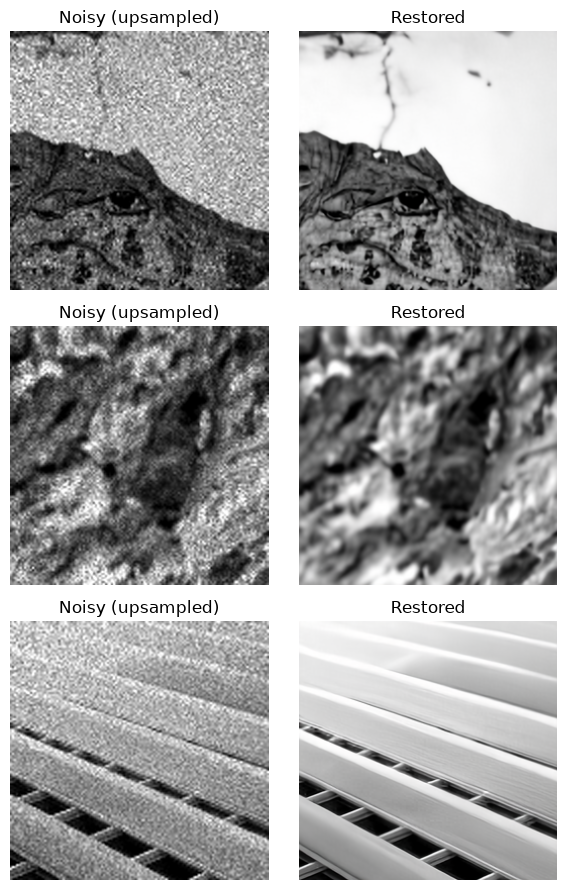

In [15]:
show_test = test_files[:3] if len(test_files) >= 3 else test_files
fig, axes = plt.subplots(len(show_test), 2, figsize=(6, 3 * len(show_test)))
if len(show_test) == 1:
    axes = axes[None, :]

for row, fname in enumerate(show_test):
    noisy_img = load_npy_image(os.path.join(CFG.test_noisy_dir, fname))
    restored = np.load(os.path.join(CFG.test_output_dir, fname))
    noisy_display = upsample_to_match(noisy_img, restored.shape[:2])

    axes[row, 0].imshow(noisy_display); axes[row, 0].set_title('Noisy (upsampled)'); axes[row, 0].axis('off')
    axes[row, 1].imshow(restored); axes[row, 1].set_title('Restored'); axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
import json

history = {
    'train_losses': train_losses,
    'train_l1s': train_l1s,
    'train_ssims': train_ssims,
    'train_sobels': train_sobels,
    'train_laps': train_laps,
    'train_contrasts': train_contrasts,
    'val_psnrs': val_psnrs,
    'val_ssims': val_ssims,
    'best_psnr': best_psnr,
}
with open('training_history_SCUNet_sharp_contrast.json', 'w') as f:
    json.dump(history, f, indent=2)
print('Saved training history to training_history_SCUNet(2).json')

Saved training history to training_history_SCUNet(2).json
